# Karelian Grapheme-to-Phoneme (G2P) with a Neural Encoder-Decoder

This notebook trains a character-level **attention-based encoder-decoder (seq2seq)** model that maps Karelian orthographic words to their IPA transcriptions, using `karelian_terms.csv` (word, IPA pairs scraped from Wiktionary).

This is a learned alternative to the rule-based transcriber in `g2p.py`. Both the grapheme (input) and phoneme (output) sequences are tokenized at the Unicode character level, so combining diacritics (e.g. palatalization `ʲ`, length `ː`, non-syllabic `̯`) are each their own output token.

Pipeline: load & clean data -> build vocabularies -> Bahdanau-attention GRU encoder/decoder -> train with teacher forcing -> evaluate with phoneme error rate (PER) and exact-match accuracy -> interactive inference.

In [1]:
import csv
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DATA_PATH = Path("karelian_terms.csv")
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
)
print("device:", DEVICE)

device: mps


## 1. Load and clean the data

The raw CSV has some exact duplicate rows and IPA transcriptions wrapped in `/slashes/`. We strip the slashes and de-duplicate on the (grapheme, phoneme) pair, keeping the surface form otherwise untouched (including the handful of multi-word and hyphenated entries).

In [2]:
def load_pairs(path: Path):
    seen = set()
    pairs = []
    with open(path, encoding="utf-8", newline="") as f:
        reader = csv.reader(f)
        for row in reader:
            if len(row) < 2:
                continue
            grapheme = row[0].strip().lower()
            phoneme = row[1].strip().strip("/")
            if not grapheme or not phoneme:
                continue
            key = (grapheme, phoneme)
            if key in seen:
                continue
            seen.add(key)
            pairs.append((grapheme, phoneme))
    return pairs


pairs = load_pairs(DATA_PATH)
print(f"{len(pairs)} unique (grapheme, phoneme) pairs")
for g, p in pairs[:5]:
    print(f"  {g!r:20s} -> {p!r}")

690 unique (grapheme, phoneme) pairs
  'abie'               -> 'ˈɑbie̯'
  'ahe'                -> 'ˈɑhe'
  'abuiäni'            -> 'ˈɑbuˌiæ̯nʲi'
  'ahašhengine'        -> 'ˈɑhɑʒˌheŋɡinʲe'
  'ahaš'               -> 'ˈɑhɑʃ'


## 2. Train / validation / test split

The dataset is small (a few hundred unique entries), so we use an 80/10/10 split.

In [3]:
shuffled = pairs[:]
random.shuffle(shuffled)

n = len(shuffled)
n_test = max(1, int(0.1 * n))
n_val = max(1, int(0.1 * n))

test_pairs = shuffled[:n_test]
val_pairs = shuffled[n_test:n_test + n_val]
train_pairs = shuffled[n_test + n_val:]

print(f"train: {len(train_pairs)}  val: {len(val_pairs)}  test: {len(test_pairs)}")

train: 552  val: 69  test: 69


## 3. Character-level vocabularies

Separate vocabularies for the grapheme (input) and phoneme (output) alphabets, each with `<pad>`, `<sos>`, `<eos>`, `<unk>` special tokens. Vocabularies are built from the training split only, so validation/test can legitimately contain `<unk>` characters.

In [4]:
PAD, SOS, EOS, UNK = "<pad>", "<sos>", "<eos>", "<unk>"
SPECIALS = [PAD, SOS, EOS, UNK]


def build_vocab(sequences):
    chars = sorted(set(ch for seq in sequences for ch in seq))
    itos = SPECIALS + chars
    stoi = {ch: i for i, ch in enumerate(itos)}
    return stoi, itos


src_stoi, src_itos = build_vocab([g for g, _ in train_pairs])
tgt_stoi, tgt_itos = build_vocab([p for _, p in train_pairs])

PAD_IDX = src_stoi[PAD]
TGT_PAD_IDX = tgt_stoi[PAD]
SOS_IDX = tgt_stoi[SOS]
EOS_IDX = tgt_stoi[EOS]

print("input vocab  (", len(src_itos), "):", src_itos)
print("output vocab (", len(tgt_itos), "):", tgt_itos)


def encode(seq, stoi):
    ids = [stoi.get(ch, stoi[UNK]) for ch in seq]
    return [stoi[SOS]] + ids + [stoi[EOS]]

input vocab  ( 34 ): ['<pad>', '<sos>', '<eos>', '<unk>', ' ', '-', 'a', 'b', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y', 'z', 'ä', 'ö', 'č', 'š', 'ž', 'ʹ']
output vocab ( 39 ): ['<pad>', '<sos>', '<eos>', '<unk>', ' ', 'a', 'b', 'd', 'e', 'f', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'y', 'z', 'æ', 'ø', 'ŋ', 'ɑ', 'ɡ', 'ʃ', 'ʋ', 'ʒ', 'ʲ', 'ˈ', 'ˌ', 'ː', '̯', '͡']


## 4. Dataset and DataLoader

Each example is padded per-batch (not globally), using `pack_padded_sequence` in the encoder for efficiency.

In [5]:
class G2PDataset(Dataset):
    def __init__(self, pairs, src_stoi, tgt_stoi):
        self.pairs = pairs
        self.src_stoi = src_stoi
        self.tgt_stoi = tgt_stoi

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        grapheme, phoneme = self.pairs[idx]
        src = torch.tensor(encode(grapheme, self.src_stoi), dtype=torch.long)
        tgt = torch.tensor(encode(phoneme, self.tgt_stoi), dtype=torch.long)
        return src, tgt


def collate_fn(batch):
    srcs, tgts = zip(*batch)
    src_lens = torch.tensor([len(s) for s in srcs])
    tgt_lens = torch.tensor([len(t) for t in tgts])
    src_pad = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    tgt_pad = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=TGT_PAD_IDX)
    return src_pad, src_lens, tgt_pad, tgt_lens


BATCH_SIZE = 32

train_ds = G2PDataset(train_pairs, src_stoi, tgt_stoi)
val_ds = G2PDataset(val_pairs, src_stoi, tgt_stoi)
test_ds = G2PDataset(test_pairs, src_stoi, tgt_stoi)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

## 5. Model: bidirectional GRU encoder + attention GRU decoder

- **Encoder**: embedding -> bidirectional GRU. The final forward/backward hidden states are combined (via a linear + tanh) to initialize the decoder.
- **Attention**: Bahdanau-style additive attention over encoder outputs, masked to ignore padding positions.
- **Decoder**: embedding + attended context fed into a GRU, one step at a time, with teacher forcing during training.

In [6]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.rnn = nn.GRU(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, src, src_lens):
        embedded = self.embedding(src)
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lens.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_out, hidden = self.rnn(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True)
        hidden = torch.tanh(self.fc(torch.cat((hidden[0], hidden[1]), dim=1)))
        return outputs, hidden  # outputs: [B, S, 2H], hidden: [B, H]


class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 3, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, dec_hidden, enc_outputs, mask):
        seq_len = enc_outputs.size(1)
        dec_hidden_rep = dec_hidden.unsqueeze(1).repeat(1, seq_len, 1)
        energy = torch.tanh(self.attn(torch.cat((dec_hidden_rep, enc_outputs), dim=2)))
        scores = self.v(energy).squeeze(2)
        scores = scores.masked_fill(mask == 0, -1e10)
        return F.softmax(scores, dim=1)


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.attention = Attention(hidden_dim)
        self.rnn = nn.GRU(emb_dim + hidden_dim * 2, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim * 3 + emb_dim, vocab_size)

    def forward(self, input_tok, hidden, enc_outputs, mask):
        embedded = self.embedding(input_tok).unsqueeze(1)  # [B, 1, E]
        attn_weights = self.attention(hidden, enc_outputs, mask)  # [B, S]
        context = torch.bmm(attn_weights.unsqueeze(1), enc_outputs)  # [B, 1, 2H]
        rnn_input = torch.cat((embedded, context), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        hidden = hidden.squeeze(0)
        output = output.squeeze(1)
        embedded = embedded.squeeze(1)
        context = context.squeeze(1)
        pred = self.fc_out(torch.cat((output, context, embedded), dim=1))
        return pred, hidden, attn_weights


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, src_pad_idx, sos_idx, eos_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx
        self.sos_idx = sos_idx
        self.eos_idx = eos_idx
        self.device = device

    def create_mask(self, src):
        return src != self.src_pad_idx

    def forward(self, src, src_lens, tgt=None, max_len=40, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        enc_outputs, hidden = self.encoder(src, src_lens)
        mask = self.create_mask(src)

        out_len = tgt.size(1) if tgt is not None else max_len
        vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(batch_size, out_len, vocab_size, device=self.device)

        input_tok = torch.full((batch_size,), self.sos_idx, dtype=torch.long, device=self.device)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

        for t in range(1, out_len):
            pred, hidden, _ = self.decoder(input_tok, hidden, enc_outputs, mask)
            outputs[:, t] = pred
            top1 = pred.argmax(1)
            if tgt is not None and torch.rand(1).item() < teacher_forcing_ratio:
                input_tok = tgt[:, t]
            else:
                input_tok = top1
            finished = finished | (top1 == self.eos_idx)
            if tgt is None and finished.all():
                break
        return outputs

## 6. Training loop

Cross-entropy loss over output characters, ignoring `<pad>` positions and the leading `<sos>` slot. Best model (by validation loss) is checkpointed to `best_g2p_model.pt`.

In [7]:
EMB_DIM = 64
HID_DIM = 256
N_EPOCHS = 60
LEARNING_RATE = 1e-3
TEACHER_FORCING_RATIO = 0.5
CHECKPOINT_PATH = "best_g2p_model.pt"

encoder = Encoder(len(src_itos), EMB_DIM, HID_DIM, PAD_IDX).to(DEVICE)
decoder = Decoder(len(tgt_itos), EMB_DIM, HID_DIM, TGT_PAD_IDX).to(DEVICE)
model = Seq2Seq(encoder, decoder, PAD_IDX, SOS_IDX, EOS_IDX, DEVICE).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable parameters: {n_params:,}")

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)


def run_epoch(dl, train: bool, teacher_forcing_ratio: float = 0.0):
    model.train() if train else model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for src, src_lens, tgt, tgt_lens in dl:
            src, tgt = src.to(DEVICE), tgt.to(DEVICE)
            if train:
                optimizer.zero_grad()
            outputs = model(src, src_lens, tgt, teacher_forcing_ratio=teacher_forcing_ratio)
            vocab_size = outputs.shape[-1]
            loss = criterion(
                outputs[:, 1:].reshape(-1, vocab_size), tgt[:, 1:].reshape(-1)
            )
            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(dl)


history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")

for epoch in range(1, N_EPOCHS + 1):
    train_loss = run_epoch(train_dl, train=True, teacher_forcing_ratio=TEACHER_FORCING_RATIO)
    val_loss = run_epoch(val_dl, train=False)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)

    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:3d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f}")

print(f"\nbest val loss: {best_val_loss:.4f} (checkpoint: {CHECKPOINT_PATH})")
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))

trainable parameters: 1,500,711
epoch   1 | train_loss 2.8148 | val_loss 2.1971
epoch   5 | train_loss 0.7564 | val_loss 0.7898
epoch  10 | train_loss 0.2986 | val_loss 0.2931
epoch  15 | train_loss 0.1696 | val_loss 0.3505
epoch  20 | train_loss 0.1059 | val_loss 0.3194
epoch  25 | train_loss 0.0865 | val_loss 0.2092
epoch  30 | train_loss 0.0300 | val_loss 0.2609
epoch  35 | train_loss 0.0139 | val_loss 0.1301
epoch  40 | train_loss 0.0915 | val_loss 0.3869
epoch  45 | train_loss 0.0068 | val_loss 0.1316
epoch  50 | train_loss 0.0132 | val_loss 0.1701
epoch  55 | train_loss 0.0039 | val_loss 0.1697
epoch  60 | train_loss 0.0015 | val_loss 0.1342

best val loss: 0.1193 (checkpoint: best_g2p_model.pt)


<All keys matched successfully>

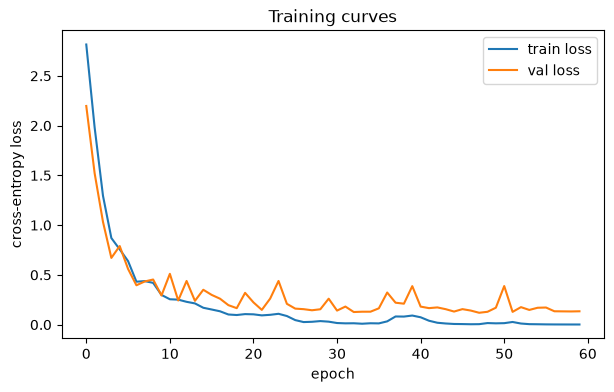

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Training curves")
plt.legend()
plt.show()

## 7. Inference (greedy decoding)

In [9]:
@torch.no_grad()
def transcribe(word: str, max_len: int = 40) -> str:
    model.eval()
    word = word.strip().lower()
    src_ids = encode(word, src_stoi)
    src = torch.tensor(src_ids, device=DEVICE).unsqueeze(0)
    src_lens = torch.tensor([len(src_ids)])

    enc_outputs, hidden = model.encoder(src, src_lens)
    mask = model.create_mask(src)

    input_tok = torch.tensor([SOS_IDX], device=DEVICE)
    result_chars = []
    for _ in range(max_len):
        pred, hidden, _ = model.decoder(input_tok, hidden, enc_outputs, mask)
        top1 = pred.argmax(1).item()
        if top1 == EOS_IDX:
            break
        result_chars.append(tgt_itos[top1])
        input_tok = torch.tensor([top1], device=DEVICE)
    return "".join(result_chars)

## 8. Evaluation: phoneme error rate (PER) and exact-match accuracy

PER is the total Levenshtein (character edit) distance between predicted and gold IPA strings, normalized by total gold length -- the same metric `g2p.py`'s `min_edit_distance` approximates for the rule-based system.

In [10]:
def levenshtein(a: str, b: str) -> int:
    m, n = len(a), len(b)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if a[i - 1] == b[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
            else:
                dp[i][j] = 1 + min(dp[i - 1][j], dp[i][j - 1], dp[i - 1][j - 1])
    return dp[m][n]


def evaluate(pairs):
    total_edits = 0
    total_len = 0
    exact = 0
    predictions = []
    for grapheme, phoneme in pairs:
        pred = transcribe(grapheme)
        total_edits += levenshtein(pred, phoneme)
        total_len += len(phoneme)
        exact += int(pred == phoneme)
        predictions.append((grapheme, phoneme, pred))
    per = total_edits / total_len
    acc = exact / len(pairs)
    return per, acc, predictions


test_per, test_acc, test_predictions = evaluate(test_pairs)
print(f"Test PER (char edit distance / gold length): {test_per * 100:.2f}%")
print(f"Test exact-match accuracy: {test_acc * 100:.2f}%")

Test PER (char edit distance / gold length): 2.43%
Test exact-match accuracy: 85.51%


In [13]:
full_per, full_acc, full_predictions = evaluate(pairs)
print(f"Full corpus PER (char edit distance / gold length): {full_per * 100:.2f}%")
print(f"Full corpus exact-match accuracy: {full_acc * 100:.2f}%")

with open('nerual_karelian_output.csv', 'w', newline='') as csvfile:
    spamwriter = csv.writer(csvfile, delimiter=',',
                            quotechar='|', quoting=csv.QUOTE_MINIMAL)
    spamwriter.writerow(["grapheme", "gold", "pred", "accuracy"])
    for grapheme, gold, pred in full_predictions:
        spamwriter.writerow([grapheme, gold, pred, round(levenshtein(pred, gold)/len(gold), 2)*100])


Full corpus PER (char edit distance / gold length): 0.64%
Full corpus exact-match accuracy: 97.10%


## 9. Try it yourself

Transcribe arbitrary Karelian words (in or out of the training vocabulary of graphemes). Unseen input characters map to `<unk>`, so wildly novel orthography may transcribe poorly -- this is expected for such a small training set.

In [14]:
for word in ["Myö kyšymmä"]:
    print(f"{word:15s} -> /{transcribe(word)}/")

Myö kyšymmä     -> /ˈmyø̯ˌkːyʃymæ/
